In [1]:
### Basic
import os,sys,glob,copy,pickle,itertools,random
import numpy as np
import importlib

### matplotlib
import matplotlib.pyplot as plt

### Astropy
from astropy.io import fits
from astropy.table import Table
from astropy.wcs import WCS
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.cosmology import Planck18

from scipy.special import erfc

In [2]:
def get_axes(header):

    n_axes = header['NAXIS']

    axes=[]

    for i in range(n_axes):
        iax = str(i+1)
        dd = header['CDELT'+iax]
        axis = header['CRVAL'+iax] + dd*(np.arange(header['NAXIS'+iax]) + header['CRPIX'+iax] - 1.000)
        axes.append(axis)

    return tuple(axes)


In [3]:
def get_detection_probability_cube(flux, SN_limit, noise_cube):

    if np.isscalar(flux):
        fluxArr = np.ones(noise_cube.shape[0])*flux
    else:
        if flux.size==1:
            fluxArr = np.ones(noise_cube.shape[0])*flux[0]
        elif flux.size == noise_cube.shape[0]:
            pass
        else:
            raise ValueError('flux must be scalar, otherwise flux.size must be equivalent to noise_cube.shape[0].')
    
    SN_cube = ((1.0 / noise_cube).T * flux).T
    
    x_cube = (SN_limit - SN_cube)/np.sqrt(2)
    detection_probability_cube = erfc(x_cube)/2.
    return detection_probability_cube


def get_random_sample(size, flux, SN_limit,
                      noise_cube,
                      axes=None,
                      fluctuate=True,
                      nfrac_accept_min=0.1):

    n_accept_min = int(size * nfrac_accept_min)

    p_cube = get_detection_probability_cube(flux, SN_limit, noise_cube)
    
    n_z, n_y, n_x = noise_cube.shape
    
    size_now = 0
    
    sample = {'ix':np.zeros(size, dtype=int),
              'iy':np.zeros(size, dtype=int),
              'iz':np.zeros(size, dtype=int)}
    
    i=0
    while size_now<size:
        ix_ran = np.random.randint(0, n_x, size)
        iy_ran = np.random.randint(0, n_y, size)
        iz_ran = np.random.randint(0, n_z, size)
        v_ran = np.random.random_sample(size)
        idx = np.where(v_ran < p_cube[iz_ran, iy_ran, ix_ran])[0]

        if idx.size > n_accept_min:
            i0 = size_now
            i1 = np.min([size, size_now+idx.size])
            sample['ix'][i0:i1] = ix_ran[idx[0:i1-i0]]
            sample['iy'][i0:i1] = iy_ran[idx[0:i1-i0]]
            sample['iz'][i0:i1] = iz_ran[idx[0:i1-i0]]
            size_now = size_now + idx.size
            i = i + 1
        else:
            raise ValueError
    
    if axes is not None:
        
        sample['x'] = axes[0][sample['ix']]
        sample['y'] = axes[1][sample['iy']]
        sample['z'] = axes[2][sample['iz']]

        if fluctuate==True:
            dran = np.random.random_sample((3, size))

            dx = axes[0][1]-axes[0][0]
            dy = axes[1][1]-axes[1][0]
            dz = axes[2][1]-axes[2][0]

            sample['x'] = sample['x']+dx*(dran[0,:]-0.5)
            sample['y'] = sample['y']+dy*(dran[1,:]-0.5)
            sample['z'] = sample['z']+dz*(dran[2,:]-0.5)
            
    return sample


def flatten_random_samples(random_samples,
                           n=None,
                           shuffle=True):

    ### n_ran per galaxy
    n_ran = random_samples['DIRIMG_X'][0].size

    ### Total n_ran
    n_ran_tot = n_ran * len(random_samples)

    ### Empty Table
    ran_cat = Table()

    if n is None:
        n = n_ran

    keys = random_samples.keys()
    for key in keys:
        if random_samples[key].shape == (len(random_samples),):
            ran_cat.add_column(np.repeat(random_samples[key], n), name=key)
        elif random_samples[key].shape == (len(random_samples),n_ran):
            ran_cat.add_column((random_samples[key])[:,0:n].flatten(), name=key)
        else:
            pass
        
    if shuffle==True:
        ind_shuffled = np.arange(len(ran_cat))
        rng = np.random.default_rng()
        rng.shuffle(ind_shuffled)
        ran_cat = ran_cat[ind_shuffled] 

    return ran_cat

def get_random_sample_for_luminosity(size, luminosity, noise_cube, axes,
                                     zlim=[5.2,7.1],
                                     SN_lim=5.0,
                                     cosmo=Planck18, wcs=None, sky_center=None, flatten=True):

    ### Line luminosity array
    if np.isscalar(luminosity):
        luminosity = np.array([luminosity])
    n_src = luminosity.size

    ### Redshift axis
    z_axis = axes[2]
    idx_zaxis_lim = np.where((z_axis>zlim[0])&(z_axis<zlim[1]))[0]
    if idx_zaxis_lim.size==0:
        idx_zaxis_lim = np.array([np.where(z_axis<zlim[0])[0][-1],
                                  np.where(z_axis>zlim[1])[0][0]])
                                     
    if idx_zaxis_lim[0]>0:
        idx_zaxis_lim = np.append(idx_zaxis_lim[0]-1, idx_zaxis_lim)
    if idx_zaxis_lim[-1]<z_axis.size-1:
        idx_zaxis_lim = np.append(idx_zaxis_lim, idx_zaxis_lim[-1]+1)

    dz_axis = z_axis[1]-z_axis[0]
    sizefact = 1+5*dz_axis/(zlim[1]-zlim[0])
    print('sizefact: ', sizefact, dz_axis/(zlim[1]-zlim[0]))
        
    ### Luminosity distance
    dl_axis = cosmo.luminosity_distance(z_axis[idx_zaxis_lim]).to_value(u.cm)
    L2F = 1./(4*np.pi*dl_axis**2)
    
    ### Empty random cats
    random_samples = Table()
    random_samples.add_column(np.ones((n_src, size))+np.nan, name='DIRIMG_X')
    random_samples.add_column(np.ones((n_src, size))+np.nan, name='DIRIMG_Y')
    random_samples.add_column(np.ones((n_src, size))+np.nan, name='z')
    random_samples.add_column(np.ones((n_src, size))+np.nan, name='dc')

    for i in range(luminosity.size):

        fluxArr = luminosity[i] * L2F
        ran_samp = get_random_sample(int(size * sizefact),
                                     fluxArr, SN_lim,
                                     noise_cube[idx_zaxis_lim,:,:],
                                     (axes[0],axes[1],z_axis[idx_zaxis_lim]),
                                     fluctuate=True)
        
        idx_ran_zlim = np.where((ran_samp['z']>zlim[0])&(ran_samp['z']<zlim[1]))[0]
        random_samples['DIRIMG_X'][i]=ran_samp['x'][idx_ran_zlim[0:size]]
        random_samples['DIRIMG_Y'][i]=ran_samp['y'][idx_ran_zlim[0:size]]
        random_samples['z'][i]=ran_samp['z'][idx_ran_zlim[0:size]]

    random_samples['dc'] = cosmo.comoving_distance(random_samples['z'])
        
    if wcs is not None:
        random_samples['skycoord'] = wcs.pixel_to_world(random_samples['DIRIMG_X'], random_samples['DIRIMG_Y'])
        if sky_center is not None: 
            random_samples.add_column(sky_center.separation(random_samples['skycoord']).to(u.arcsec), name='sep_qso')
            random_samples.add_column(random_samples['dc'].value*(random_samples['sep_qso'].value * u.arcsec).to_value(u.radian), 
                                      name='sep_qso_cMpc')

    if flatten:
        return flatten_random_samples(random_samples, shuffle=True)
    else:
        return random_samples
                      


In [4]:
cat = Table.read('O3_emitters_v20221012.fits')

noise_cube.shape:  (45, 49, 94)


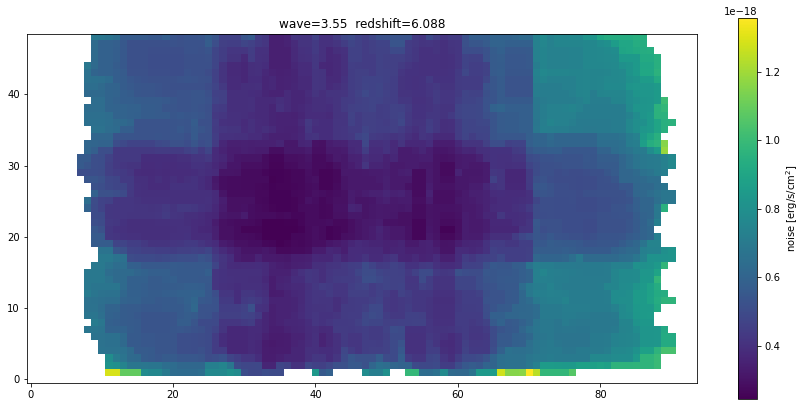

In [5]:

### Noise cube
### The fits file contain a cube of 3-sigma limiting flux,
### so it will be a noise cube by dividing by 3.
noise_cube_fil = 'test_limitingflux_evenlessoverlap_v20221006_JM.fits'
noise_cube = fits.getdata(noise_cube_fil)/3. * 1e-18 * u.erg/u.s/u.cm**2
print('noise_cube.shape: ', noise_cube.shape)

### Get axes [DirectImage_X, DirectImage_Y, Wavelength-axis]
noise_cube_header = fits.getheader(noise_cube_fil)
noise_cube_axes = get_axes(noise_cube_header)  # 

### Convert wavelength [um] to redshift (w_5008 = 5008.24)
noise_cube_axis_zO3 = (noise_cube_axes[2]*1e4)/5008.24 - 1
noise_cube_axes_zO3 = (noise_cube_axes[0], noise_cube_axes[1], noise_cube_axis_zO3)


iz = 20
fig = plt.figure(figsize=(15,7))
ax = fig.add_subplot()

cmap = ax.imshow(noise_cube[iz,:,:].value, origin='lower')
ax.set_title('wave={}'.format(noise_cube_axes[2][iz])+'  redshift={:.3f}'.format(noise_cube_axis_zO3[iz]))
fig.colorbar(cmap, label=r'noise [$\mathrm{erg/s/cm^2}$]')


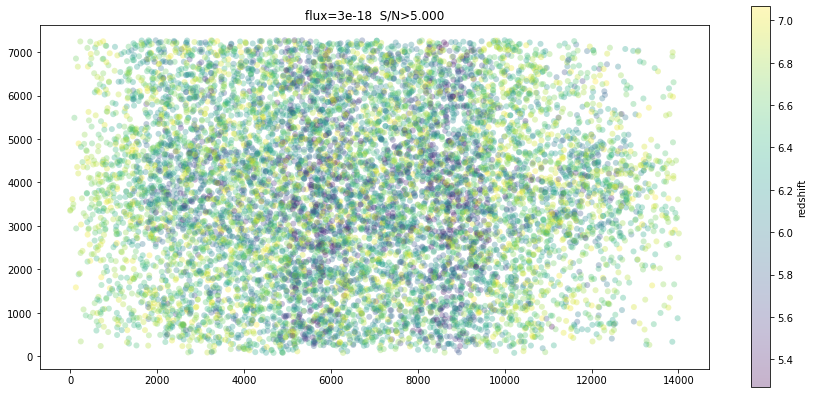

In [6]:
### Get random sample of (X, Y, redshift) for a given flux and limiting S/N
### Prior redshift distribution is uniform across the window.
size = 10000
flux = 3e-18
SN_lim = 5.0
rand_samp = get_random_sample(size, flux, SN_lim, noise_cube.value, axes=noise_cube_axes_zO3, fluctuate=True)

fig = plt.figure(figsize=(15,7))
ax = fig.add_subplot()

cmap = ax.scatter(rand_samp['x'], rand_samp['y'], c=rand_samp['z'], alpha=0.3, ec='none')
ax.set_title('flux={}'.format(flux)+'  S/N>{:.3f}'.format(SN_lim))
ax.axis('scaled')
fig.colorbar(cmap, label=r'redshift')



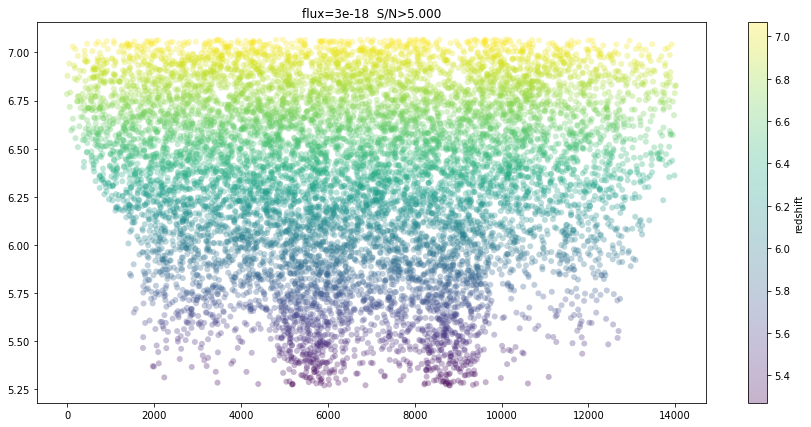

In [7]:
fig = plt.figure(figsize=(15,7))
ax = fig.add_subplot()

cmap = ax.scatter(rand_samp['x'], rand_samp['z'], c=rand_samp['z'], alpha=0.3, ec='none')
ax.set_title('flux={}'.format(flux)+'  S/N>{:.3f}'.format(SN_lim))
fig.colorbar(cmap, label=r'redshift')



In [8]:
### Direct image and WCS
dirimg_fil = 'stack_F356W_pipe4_v2_fluxcal_20220831.fits'
wcs = WCS(fits.getheader(dirimg_fil,1))

### QSO information
z_qso = 6.3269
qso_sky = SkyCoord(ra='01h00m13.0243195069s', dec='+28d02m25.790102480s', frame='icrs')
qso_sky
qso_dirimg_x, qso_dirimg_y = wcs.world_to_pixel(qso_sky)
qso_sky

Set DATE-AVG to '2022-08-23T02:43:15.660' from MJD-AVG.
Set DATE-END to '2022-08-24T01:16:06.419' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -24.196722 from OBSGEO-[XYZ].
Set OBSGEO-H to 1570804476.287 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


<SkyCoord (ICRS): (ra, dec) in deg
    (15.054268, 28.04049725)>

index_O3_zlim.size  28
sizefact:  8.131105081682504 1.4262210163365008


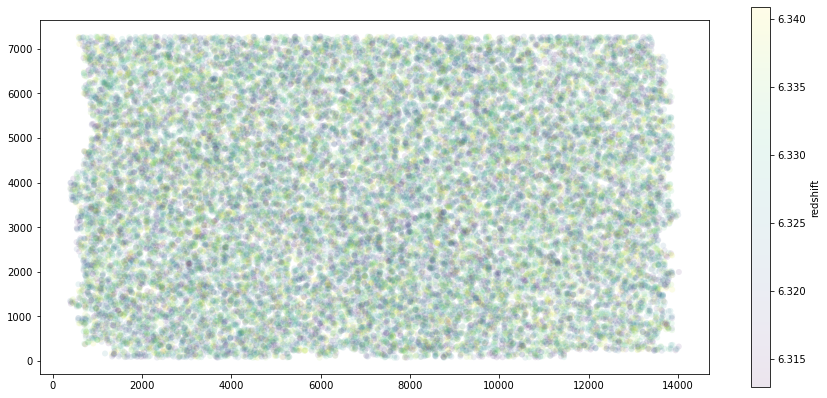

In [9]:
### Get random sample for a limited redshift range with a list of observed luminosities
### Assume the same "luminosity" distribution of a given galaxy sample

### Redshift range for the QSO environment
zlim = 6.3269 + 0.014*np.array([-1,1])

### Select galaxies
index_O3_zlim = np.where((cat['z']>zlim[0])&
                         (cat['z']<zlim[1]))[0]
print('index_O3_zlim.size ', index_O3_zlim.size)


### Total random sample size will be size_per_gal times number_of_gals
size_per_gal = 1000
luminosity_list = cat['L_O3'][index_O3_zlim]

### If comology is given, comoving_distance will be calculated.
### If wcs is given, RA and DEC will be calculated.
### If sky_center is given, the angular separations will be calculated.
ran_cat = get_random_sample_for_luminosity(size_per_gal, 
                                           luminosity_list,
                                           noise_cube.value,
                                           noise_cube_axes_zO3,
                                           zlim=zlim,
                                           SN_lim=5.0,
                                           cosmo=Planck18,
                                           wcs=wcs, 
                                           sky_center=qso_sky,
                                           flatten=True)

fig = plt.figure(figsize=(15,7))
ax = fig.add_subplot()

cmap = ax.scatter(ran_cat['DIRIMG_X'], 
                  ran_cat['DIRIMG_Y'], 
                  c=ran_cat['z'], alpha=0.1, ec='none')
ax.axis('scaled')
fig.colorbar(cmap, label=r'redshift')


index_O3_zlim.size  28
sizefact:  1.332784903811856 0.0665569807623712


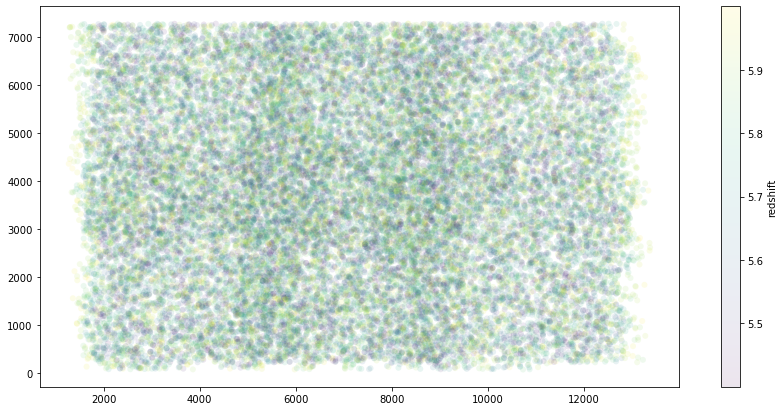

In [10]:
### Another example
zlim = [5.4, 6.0]

index_O3_zlim = np.where((cat['z']>zlim[0])&
                         (cat['z']<zlim[1]))[0]
print('index_O3_zlim.size ', index_O3_zlim.size)


size_per_gal = 1000

### With faint luminosities
luminosity_list = cat['L_O3'][index_O3_zlim] * 0.6

ran_cat = get_random_sample_for_luminosity(size_per_gal, 
                                           luminosity_list,
                                           noise_cube.value,
                                           noise_cube_axes_zO3,
                                           zlim=zlim,
                                           SN_lim=5.0,
                                           cosmo=Planck18,
                                           wcs=wcs, 
                                           sky_center=qso_sky,
                                           flatten=True)

fig = plt.figure(figsize=(15,7))
ax = fig.add_subplot()

cmap = ax.scatter(ran_cat['DIRIMG_X'], 
                  ran_cat['DIRIMG_Y'], 
                  c=ran_cat['z'], alpha=0.1, ec='none')
ax.axis('scaled')
fig.colorbar(cmap, label=r'redshift')
